<a href="https://colab.research.google.com/github/karinenoronha/Acidentente_PRF_2026/blob/main/acidentes_PRF_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



Os acidentes em rodovias federais geram impactos sociais e econômicos significativos.

O objetivo desta análise é identificar:

Onde ocorrem mais acidentes
Quando eles acontecem
Quais são as principais causas
Quais fatores estão associados aos acidentes mais graves

Os resultados podem auxiliar ações de fiscalização, conscientização e prevenção.

Dados abertos da PRF : https://www.gov.br/prf/pt-br/acesso-a-informacao/dados-abertos/dados-abertos-da-prf

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
data_tran = pd.read_csv("acidentes2026_todas_causas_tipos.csv", encoding='latin1', sep=';')

In [6]:
data_tran.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196099 entries, 0 to 196098
Data columns (total 37 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      196099 non-null  int64  
 1   pesid                   176922 non-null  float64
 2   data_inversa            196099 non-null  object 
 3   dia_semana              196099 non-null  object 
 4   horario                 196099 non-null  object 
 5   uf                      196099 non-null  object 
 6   br                      195766 non-null  float64
 7   km                      195766 non-null  object 
 8   municipio               196099 non-null  object 
 9   causa_principal         196099 non-null  object 
 10  causa_acidente          196099 non-null  object 
 11  ordem_tipo_acidente     196099 non-null  int64  
 12  tipo_acidente           196099 non-null  object 
 13  classificacao_acidente  195979 non-null  object 
 14  fase_dia            

In [7]:
data_tran.head()

,id,pesid,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_principal,...,sexo,ilesos,feridos_leves,feridos_graves,mortos,latitude,longitude,regional,delegacia,uop
0,742884,1663693.0,2026-01-01,quinta-feira,00:05:00,SC,101.0,145,ITAPEMA,Sim,...,Masculino,0.0,1.0,0.0,0.0,"-27,08476806","-48,60635638",SPRF-SC,DEL04-SC,UOP03-DEL04-SC
1,742885,1663697.0,2026-01-01,quinta-feira,00:20:00,PR,376.0,"639,3",TIJUCAS DO SUL,Não,...,Masculino,1.0,0.0,0.0,0.0,"-25,783081","-49,120916",SPRF-PR,DEL01-PR,UOP04-DEL01-PR
2,742885,1663697.0,2026-01-01,quinta-feira,00:20:00,PR,376.0,"639,3",TIJUCAS DO SUL,Não,...,Masculino,1.0,0.0,0.0,0.0,"-25,783081","-49,120916",SPRF-PR,DEL01-PR,UOP04-DEL01-PR
3,742885,1663697.0,2026-01-01,quinta-feira,00:20:00,PR,376.0,"639,3",TIJUCAS DO SUL,Sim,...,Masculino,1.0,0.0,0.0,0.0,"-25,783081","-49,120916",SPRF-PR,DEL01-PR,UOP04-DEL01-PR
4,742888,1663874.0,2026-01-01,quinta-feira,00:05:00,MG,262.0,108,SANTO ANTONIO DO GRAMA,Sim,...,Masculino,1.0,0.0,0.0,0.0,"-20,27038974","-42,57027627",SPRF-MG,DEL03-MG,UOP03-DEL03-MG


In [11]:
data_tran.tail()

,id,pesid,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_principal,...,sexo,ilesos,feridos_leves,feridos_graves,mortos,latitude,longitude,regional,delegacia,uop
196094,772109,1737210.0,2026-04-29,quarta-feira,23:00:00,GO,20.0,"11,5",FORMOSA,Sim,...,Masculino,1.0,0.0,0.0,0.0,"-15,56454108","-47,25199568",SPRF-DF,DEL02-DF,UOP02-DEL02-DF
196095,772109,1737209.0,2026-04-29,quarta-feira,23:00:00,GO,20.0,"11,5",FORMOSA,Sim,...,Masculino,0.0,0.0,0.0,1.0,"-15,56454108","-47,25199568",SPRF-DF,DEL02-DF,UOP02-DEL02-DF
196096,772176,NaN,2026-04-19,domingo,04:10:00,PE,101.0,126,ESCADA,Sim,...,NaN,NaN,NaN,NaN,NaN,"-8,369917","-35,229762",SPRF-PE,DEL01-PE,UOP03-DEL01-PE
196097,772176,1737436.0,2026-04-19,domingo,04:10:00,PE,101.0,126,ESCADA,Sim,...,Masculino,1.0,0.0,0.0,0.0,"-8,369917","-35,229762",SPRF-PE,DEL01-PE,UOP03-DEL01-PE
196098,772176,1737435.0,2026-04-19,domingo,04:10:00,PE,101.0,126,ESCADA,Sim,...,Masculino,0.0,1.0,0.0,0.0,"-8,369917","-35,229762",SPRF-PE,DEL01-PE,UOP03-DEL01-PE


In [10]:
data_tran.describe()


,id,pesid,br,ordem_tipo_acidente,id_veiculo,ano_fabricacao_veiculo,idade,ilesos,feridos_leves,feridos_graves,mortos
count,196099.000000,1.769220e+05,195766.000000,196099.000000,1.904890e+05,190489.000000,162563.000000,176922.000000,176922.000000,176922.000000,176922.000000
mean,755845.042734,1.697114e+06,219.462854,1.788107,1.351445e+06,1913.365297,39.716750,0.416172,0.351805,0.121669,0.050237
std,7599.346054,1.905501e+04,128.212395,1.114029,1.483857e+04,440.789720,25.041874,0.492924,0.477535,0.326905,0.218434
min,742884.000000,1.663693e+06,10.000000,1.000000,1.326454e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,749300.500000,1.680740e+06,104.000000,1.000000,1.338643e+06,2009.000000,28.000000,0.000000,0.000000,0.000000,0.000000
50%,755530.000000,1.696847e+06,210.000000,1.000000,1.350706e+06,2015.000000,38.000000,0.000000,0.000000,0.000000,0.000000
75%,762533.000000,1.713768e+06,354.000000,2.000000,1.364601e+06,2022.000000,50.000000,1.000000,1.000000,0.000000,0.000000
max,772176.000000,1.737879e+06,495.000000,14.000000,1.383658e+06,2026.000000,2025.000000,1.000000,1.000000,1.000000,1.000000


In [12]:
#Transformando as variaveis em uma lista
list(data_tran.columns)

['id',
 'pesid',
 'data_inversa',
 'dia_semana',
 'horario',
 'uf',
 'br',
 'km',
 'municipio',
 'causa_principal',
 'causa_acidente',
 'ordem_tipo_acidente',
 'tipo_acidente',
 'classificacao_acidente',
 'fase_dia',
 'sentido_via',
 'condicao_metereologica',
 'tipo_pista',
 'tracado_via',
 'uso_solo',
 'id_veiculo',
 'tipo_veiculo',
 'marca',
 'ano_fabricacao_veiculo',
 'tipo_envolvido',
 'estado_fisico',
 'idade',
 'sexo',
 'ilesos',
 'feridos_leves',
 'feridos_graves',
 'mortos',
 'latitude',
 'longitude',
 'regional',
 'delegacia',
 'uop']

In [13]:
def generate_metadata(dataframe):
    """
    Gera um dataframe contendo metadados das colunas do dataframe fornecido.

    :param dataframe: DataFrame para o qual os metadados serão gerados.
    :return: DataFrame contendo metadados.
    """

    # Coleta de metadados básicos
    metadata = pd.DataFrame({
        'nome_variavel': dataframe.columns,
        'tipo': dataframe.dtypes,
        'qt_nulos': dataframe.isnull().sum(),
        'percent_nulos': round((dataframe.isnull().sum() / len(dataframe))* 100,2),
        'cardinalidade': dataframe.nunique(),
    })
    metadata=metadata.sort_values(by='tipo')
    metadata = metadata.reset_index(drop=True)

    return metadata

# Testando a função com o dataframe dados_prf_2023
metadata_data_tran = generate_metadata(data_tran)
metadata_data_tran

,nome_variavel,tipo,qt_nulos,percent_nulos,cardinalidade
0,id,int64,0,0.00,23476
1,ordem_tipo_acidente,int64,0,0.00,14
2,ano_fabricacao_veiculo,float64,5610,2.86,67
3,idade,float64,33536,17.10,103
4,feridos_leves,float64,19177,9.78,2
5,feridos_graves,float64,19177,9.78,2
6,ilesos,float64,19177,9.78,2
7,mortos,float64,19177,9.78,2
8,pesid,float64,19177,9.78,58526
9,br,float64,333,0.17,108


In [15]:
data_tran.shape

(196099, 37)

In [18]:
# Convertendo datas

data_tran['data_inversa'] = pd.to_datetime(data_tran['data_inversa'])




In [19]:
#MÊs
data_tran['mes'] = data_tran['data_inversa'].dt.month



In [20]:
#Hora
data_tran['hora'] = pd.to_datetime(data_tran['horario']).dt.hour

/tmp/ipykernel_5944/3056265341.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data_tran['hora'] = pd.to_datetime(data_tran['horario']).dt.hour


In [21]:
#Indocador de gravidade

data_tran['gravidade'] = (
    data_tran['mortos']*3 +
    data_tran['feridos_graves']*2 +
    data_tran['feridos_leves']
)

Onde os acidentes acontecem?

In [22]:

acidentes_uf = (
    data_tran.groupby('uf')['id']
    .nunique()
    .sort_values(ascending=False)
)

<Axes: xlabel='uf'>

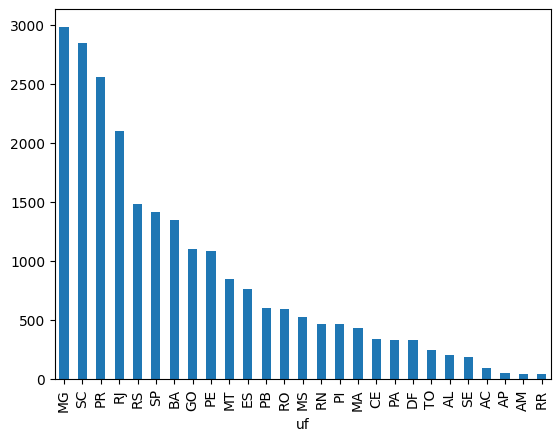

In [23]:
acidentes_uf.plot (kind= 'bar')

Insight: Minas Gerais, Santa Catarina e Parana concentram o maior número de acidentes registrados.

In [25]:
municipios = (data_tran.groupby('municipio')['id'].nunique().sort_values(ascending=False).head(10))

<Axes: ylabel='municipio'>

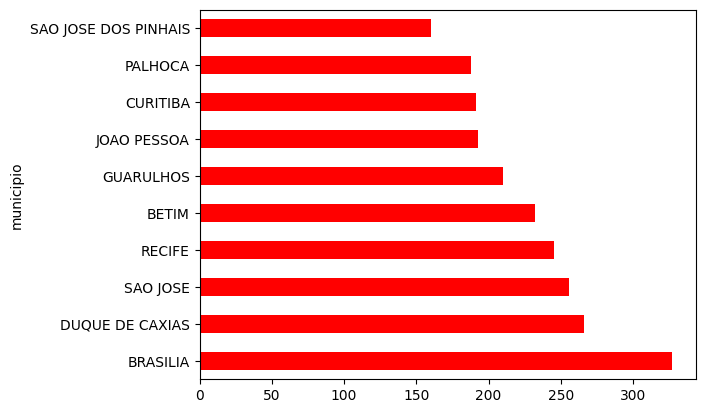

In [27]:
municipios.plot(kind='barh',color = 'red')

Insight : As cidades que mais concentram acidentes são Brasilia, Duque de Caxias e Sao Jose. Nenhuma delas está entre os très Estados que lideram o ranking de acidentes

<Axes: ylabel='br'>

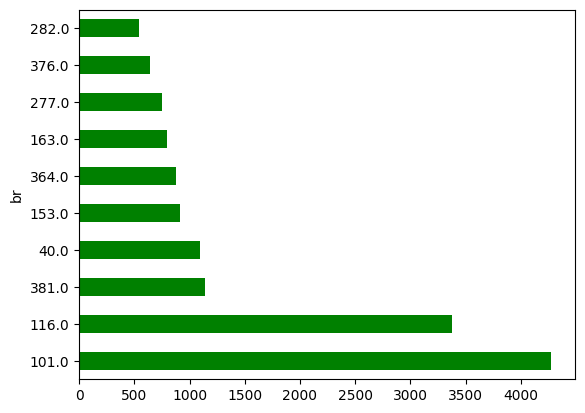

In [31]:
# TOP BRs

brs = data_tran.groupby('br')['id'].nunique().sort_values(ascending=False).head(10)

brs.plot(kind='barh',color = 'green')

As BR-101 (RN a RS), BR-116 (CE a RS) e BR-381 (ES a SP) lideram em número de acidentes no período analisado, refletindo seu alto fluxo de veículos e grande extensão.


**Quando os acidentes acontecem ?**

In [34]:
data_tran['nome_mes'] = data_tran['data_inversa'].dt.month_name()

<Axes: xlabel='nome_mes'>

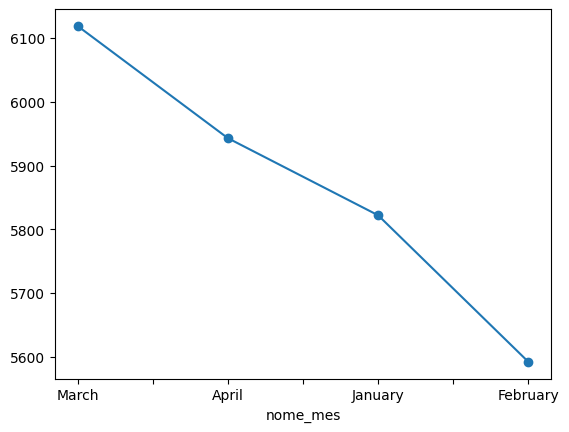

In [36]:
meses = data_tran.groupby('nome_mes')['id'].nunique().sort_values(ascending=False)
meses.plot (kind ='line',marker = 'o')

Insght: Março e abril sao os meses que mais possuem acidentes.

<Axes: ylabel='dia_semana'>

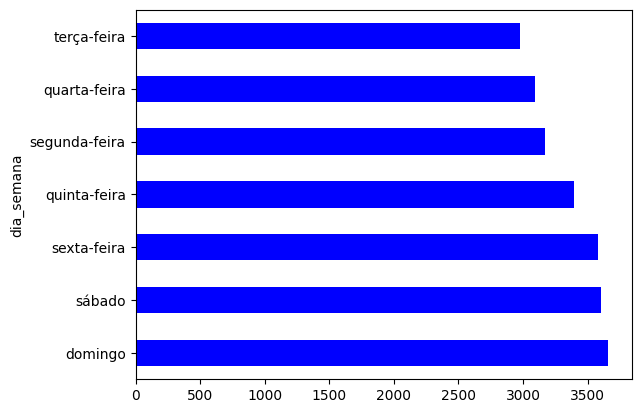

In [37]:
#Acidentes por dias da semana

dias = data_tran.groupby('dia_semana')['id'].nunique().sort_values(ascending=False)
dias.plot(kind='barh',color = 'blue')

Insight :  Os dias do final de semana são os que concentram maior numero de acidentes

<Axes: title={'center': 'Acidentes por hora'}, xlabel='hora'>

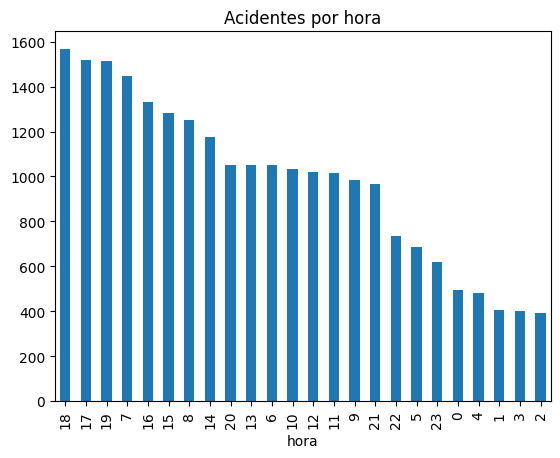

In [40]:
#Acidente por hora

horas = data_tran.groupby('hora')['id'].nunique().sort_values(ascending=False)
horas.plot(kind='bar', title='Acidentes por hora')



Insght : Os horarios que mais possuem acidentes são quando a maioria da populaçãpo esta tornando a casa, depois do trabalho

<Axes: ylabel='causa_acidente'>

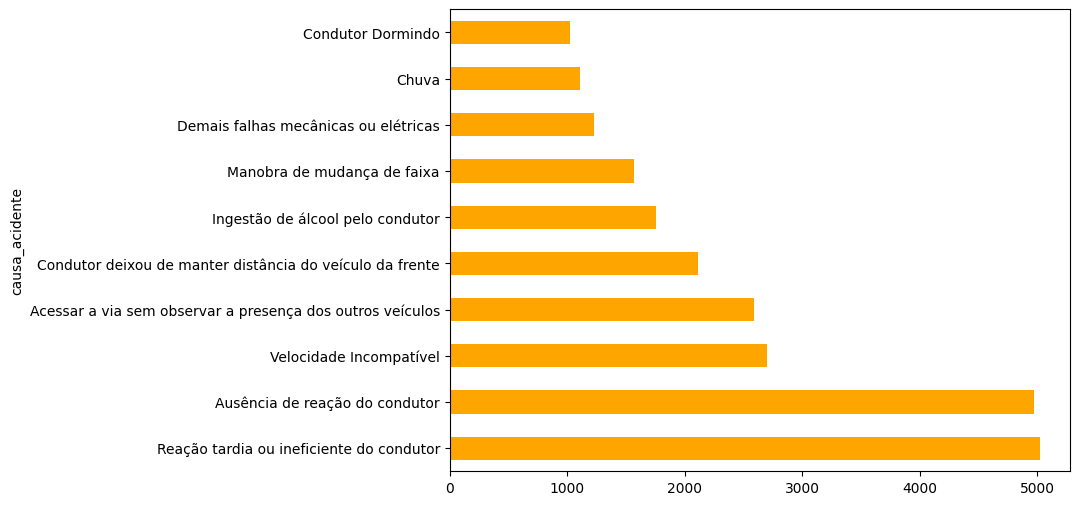

In [54]:
#Causas de acidentes

causas = data_tran.groupby('causa_acidente')['id'].nunique().sort_values(ascending=False).head(10)
causas.plot(kind='barh',color = 'orange', figsize=(8 ,6))

insight _ As principais causas estão relacionadas ao comportamento humano, sugerindo que campanhas educativas e fiscalização podem reduzir significativamente os acidentes.

<Axes: ylabel='tipo_acidente'>

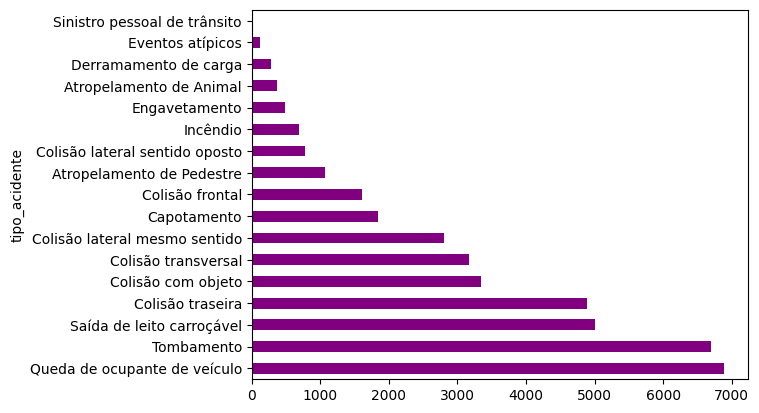

In [55]:
# Tipos de acidentes

tipos = data_tran.groupby('tipo_acidente')['id'].nunique().sort_values(ascending=False)
tipos.plot(kind='barh',color = 'purple')

GRAVIDADE DO ACIDENTES

<Axes: xlabel='causa_acidente'>

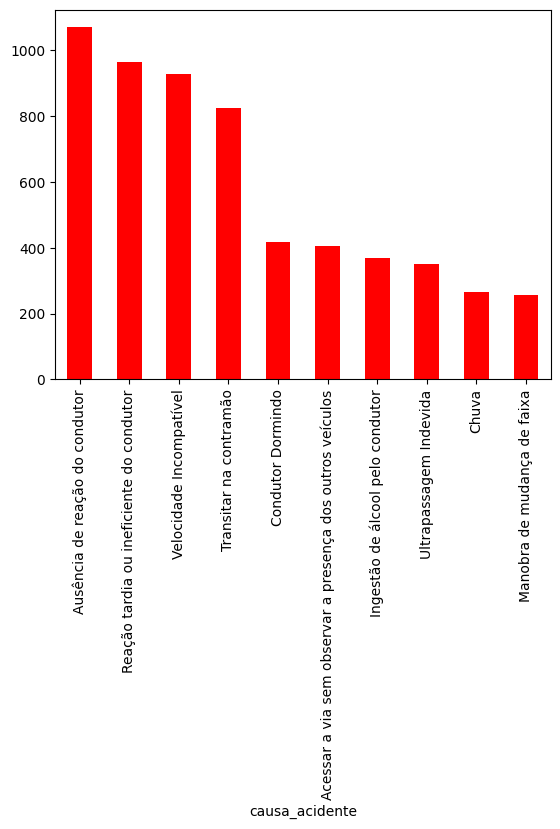

In [58]:
# Acidente com mortos

mortes_causa = data_tran.groupby('causa_acidente')['mortos'].sum().sort_values(ascending=False).head(10)

mortes_causa.plot (kind ='bar',color = 'red')

<Axes: xlabel='tipo_acidente'>

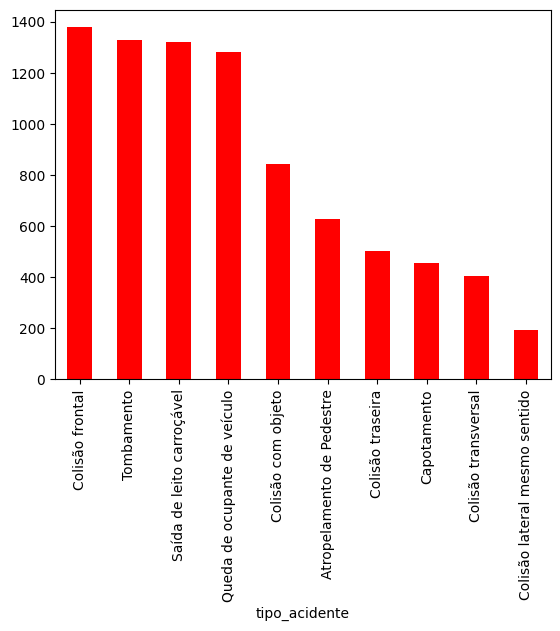

In [59]:
#mortes por tipo de acidente

mortes_tipo = data_tran.groupby('tipo_acidente')['mortos'].sum().sort_values(ascending=False).head(10)

mortes_tipo.plot (kind ='bar',color = 'red')
#

Insight : Nem sempre a causa que mais gera acidentes é a que mais mata.

In [61]:
# Perfil das vitimas

data_tran['sexo'].value_counts()

,count
sexo,
Masculino,121253
Feminino,44708
Não Informado,10636
Ignorado,325


In [62]:
data_tran['idade'].describe()

,idade
count,162563.000000
mean,39.716750
std,25.041874
min,0.000000
25%,28.000000
50%,38.000000
75%,50.000000
max,2025.000000


In [66]:
data_tran[['latitude','longitude']].isnull().sum()

,0
latitude,0
longitude,0
